# Feature Selection Method Comparison

Each section covers one model. Within each section the same train/test split is used to rank features by four methods — SHAP, Gain, LIME, and Information Gain — then evaluates top-k (k = 1…10) features and plots a per-metric comparison.

## Setup

In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import copy
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             average_precision_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from lime.lime_tabular import LimeTabularExplainer

import lightgbm as lgb
import xgboost as xgb
import importlib
import bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison


In [184]:
for mod in (bootstrap, distribution_estimation, plotting, model_wrapper, performance_comparison):
    importlib.reload(mod)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *
print("Modules reloaded.")

Modules reloaded.


### Data

In [185]:
seed = 7
os.makedirs(f"figures/musk_{seed}", exist_ok=True)

In [186]:
from sklearn.datasets import fetch_openml
import pandas as pd

musk = fetch_openml(name="musk", version=1, as_frame=True)
df = musk.frame

# target is 'class': 0 = non-musk, 1 = musk
y = df["class"].astype(int)

# drop the ID-like columns that aren't real features
drop_cols = [c for c in ["class", "molecule_name", "conformation_name", "ID"]
             if c in df.columns]
X = df.drop(columns=drop_cols)

print("X shape:", X.shape)          # expected (6598, 166)
print("Class balance:\n", y.value_counts())

X shape: (6598, 166)
Class balance:
 class
0    5581
1    1017
Name: count, dtype: int64


In [187]:
X_standard = StandardScaler().fit_transform(X)
X = pd.DataFrame(X_standard, columns=X.columns)

Y = y.astype(int) 

In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=seed, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5278, 166), Test: (1320, 166)


### Model Wrappers

In [189]:
lgb_wrapper = create_model_wrapper(
    'lightgbm',
    params={
        'objective': 'binary', 'metric': 'binary_logloss',
        'learning_rate': 0.1, 'max_depth': 8, 'num_leaves': 31,
        'min_data_in_leaf': 15, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 1,
        'verbose': -1, 'seed': seed, 'num_threads': 1,
    },
    num_boost_round=150,
)

xgb_wrapper = create_model_wrapper(
    'xgboost',
    params={
        'objective': 'binary:logistic', 'eval_metric': 'logloss',
        'eta': 0.1, 'max_depth': 6, 'subsample': 0.8,
        'colsample_bytree': 0.6, 'seed': seed,
    },
    num_boost_round=100,
)

rf_wrapper = create_model_wrapper(
    'sklearn', model_class=RandomForestClassifier,
    model_params={'n_estimators': 100, 'random_state': seed, 'max_depth': 6},
    use_tree_explainer=True,
)

cb_wrapper = create_model_wrapper(
    'catboost',
    params={'random_seed': seed, 'learning_rate': 0.1, 'depth': 6, 'eval_metric': 'Logloss'},
)

gb_wrapper = create_model_wrapper(
    'sklearn', model_class=GradientBoostingClassifier,
    model_params={'n_estimators': 200, 'max_depth': 3, 'random_state': seed},
    use_tree_explainer=True,
)

lr_wrapper = create_model_wrapper(
    'sklearn', model_class=LogisticRegression,
    model_params={'random_state': seed, 'max_iter': 200},
    use_linear_explainer=True, use_tree_explainer=False,
)

MODELS = {
    'LightGBM':          lgb_wrapper,
    'XGBoost':           xgb_wrapper,
    'RandomForest':      rf_wrapper,
    'CatBoost':          cb_wrapper,
    'GradientBoosting':  gb_wrapper,
    'LogisticRegression': lr_wrapper,
}


### Helper Functions

In [190]:
def _clone_wrapper(wrapper, input_dim=None):
    if isinstance(wrapper, XGBoostWrapper):
        return XGBoostWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, LightGBMWrapper):
        return LightGBMWrapper(params=wrapper.params.copy(), num_boost_round=wrapper.num_boost_round)
    if isinstance(wrapper, SklearnWrapper):
        return SklearnWrapper(
            model_class=wrapper.model_class,
            model_params=wrapper.model_params.copy(),
            use_tree_explainer=wrapper.use_tree_explainer,
            use_linear_explainer=wrapper.use_linear_explainer,
        )
    if isinstance(wrapper, CatBoostWrapper):
        return CatBoostWrapper(params=wrapper.params.copy(), num_boost_round=getattr(wrapper, 'num_boost_round', 100))
    return copy.deepcopy(wrapper)


def _predict_proba(wrapper, X):
    if isinstance(wrapper, XGBoostWrapper):
        p = wrapper.model.predict(xgb.DMatrix(X, enable_categorical=True))
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, LightGBMWrapper):
        p = wrapper.model.predict(X)
        return np.column_stack([1 - p, p]) if p.ndim == 1 else p
    if isinstance(wrapper, (CatBoostWrapper, SklearnWrapper)):
        return wrapper.model.predict_proba(X)
    raise TypeError(f'Unknown wrapper: {type(wrapper)}')


def get_shap_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
        task = 'binary'
        sv = w.compute_shap(X_tr, task=task)
    importance = np.abs(sv).sum(axis=tuple(range(sv.ndim - 1)))
    return (
        pd.DataFrame({'feature': X_tr.columns, 'importance': importance})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_gain_ranking(wrapper, X_tr, y_tr):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    if isinstance(w, LightGBMWrapper):
        imp = w.model.feature_importance(importance_type='gain').astype(float)
    elif isinstance(w, XGBoostWrapper):
        scores = w.model.get_score(importance_type='gain')
        imp = np.array([scores.get(f, 0.0) for f in X_tr.columns], dtype=float)
    elif isinstance(w, CatBoostWrapper):
        imp = np.array(w.model.get_feature_importance(), dtype=float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'feature_importances_'):
        imp = w.model.feature_importances_.astype(float)
    elif isinstance(w, SklearnWrapper) and hasattr(w.model, 'coef_'):
        imp = np.abs(w.model.coef_).ravel().astype(float)
    else:
        return None
    return (
        pd.DataFrame({'feature': X_tr.columns.tolist(), 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


def get_lime_ranking(wrapper, X_tr, y_tr, n_samples=10, num_features=50):
    w = _clone_wrapper(wrapper, input_dim=X_tr.shape[1])
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w.fit(X_tr, y_tr)
    X_arr = X_tr.values.astype(float)
    feat_names = X_tr.columns.tolist()
    def _pred(arr, _w=w):
        return _predict_proba(_w, pd.DataFrame(arr, columns=feat_names))
    explainer = LimeTabularExplainer(
        X_arr, feature_names=feat_names,
        class_names=['0', '1'], mode='classification', random_state=42,
    )
    idx = np.random.RandomState(42).choice(len(X_arr), min(n_samples, len(X_arr)), replace=False)
    imp = np.zeros(len(feat_names))
    for i in idx:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            exp = explainer.explain_instance(X_arr[i], _pred, num_features=num_features)
        for fi, w_val in exp.local_exp[1]:
            imp[fi] += abs(w_val)
    imp /= len(idx)
    return (
        pd.DataFrame({'feature': feat_names, 'importance': imp})
        .sort_values('importance', ascending=False).reset_index(drop=True)
    )


# def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
#     results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
#     for k in k_values:
#         feats = ranking_df['feature'].head(k).tolist()
#         try:
#             w = _clone_wrapper(wrapper, input_dim=k)
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 w.fit(X_tr[feats], y_tr)
#                 proba = _predict_proba(w, X_te[feats])
#             p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
#             y_pred = (p_pos >= 0.5).astype(int)
#             results['accuracy'].append(accuracy_score(y_te, y_pred))
#             results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
#             results['ap'].append(average_precision_score(y_te, p_pos))
#             results['auc'].append(roc_auc_score(y_te, p_pos))
#         except Exception as e:
#             for m in results:
#                 results[m].append(float('nan'))
#     return results

def evaluate_topk(wrapper, ranking_df, X_tr, X_te, y_tr, y_te, k_values=range(1, 11)):
    results = {'accuracy': [], 'f1': [], 'ap': [], 'auc': []}
    for k in k_values:
        selected = ranking_df['feature'].head(k).tolist()
        selected_set = set(selected)
        feats = [c for c in X_tr.columns if c in selected_set]  # fixed order

        try:
            w = _clone_wrapper(wrapper, input_dim=len(feats))
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                w.fit(X_tr[feats], y_tr)
                proba = _predict_proba(w, X_te[feats])
            p_pos = proba[:, 1] if proba.shape[1] >= 2 else proba.ravel()
            y_pred = (p_pos >= 0.5).astype(int)
            results['accuracy'].append(accuracy_score(y_te, y_pred))
            results['f1'].append(f1_score(y_te, y_pred, zero_division=0))
            results['ap'].append(average_precision_score(y_te, p_pos))
            results['auc'].append(roc_auc_score(y_te, p_pos))
        except Exception:
            for m in results:
                results[m].append(float('nan'))
    return results


def plot_comparison(model_name, all_results, k_values=list(range(1, 11))):
    metric_keys   = ['accuracy', 'f1',       'ap',                'auc'    ]
    metric_titles = ['Accuracy', 'F1 Score', 'Average Precision', 'AUC-ROC']
    method_styles = {
        'SHAP': dict(color='steelblue',  linestyle='-',  marker='o'),
        'Gain': dict(color='darkorange', linestyle='--', marker='s'),
        'LIME': dict(color='green',      linestyle='-.', marker='^'),
        'IG':   dict(color='crimson',    linestyle=':',  marker='D'),
        'Robust': dict(color='purple',   linestyle='-',  marker='X'),
    }
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
    for ax, key, title in zip(axes.flatten(), metric_keys, metric_titles):
        for method, res in all_results.items():
            if res is None:
                continue
            ax.plot(k_values, res[key], linewidth=1.8, markersize=5,
                    label=method, **method_styles.get(method, {}))
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('k (number of features)')
        ax.set_ylabel(title)
        ax.set_xticks(k_values)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'{model_name} — Feature Selection Comparison',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig(f"figures/musk_{seed}/musk_{model_name}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()


### Information Gain Ranking (computed once, model-agnostic)

In [191]:
print('Computing Information Gain scores...')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    ig_scores = mutual_info_classif(X_train, y_train, random_state=42)

ig_ranking = (
    pd.DataFrame({'feature': X_train.columns, 'importance': ig_scores})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
print('Top-10 IG features:')
ig_ranking.head(10)


Computing Information Gain scores...
Top-10 IG features:


,feature,importance
0,f151,0.180482
1,f162,0.173558
2,f92,0.170138
3,f166,0.161937
4,f36,0.161378
5,f102,0.153802
6,f163,0.146658
7,f110,0.138091
8,f3,0.133002
9,f42,0.132398


---
## LightGBM

### LightGBM — SHAP

In [192]:
print('Computing SHAP ranking for LightGBM...')
lightgbm_shap = get_shap_ranking(MODELS['LightGBM'], X_train, y_train)
print('Top-10:')
lightgbm_shap.head(10)


Computing SHAP ranking for LightGBM...
Top-10:


,feature,importance
0,f111,2829.433501
1,f36,2585.747231
2,f163,2081.387094
3,f66,1986.172840
4,f1,1945.659057
5,f117,1895.468548
6,f59,1870.952662
7,f67,1645.540274
8,f126,1607.977002
9,f105,1436.970061


### LightGBM — Gain

In [193]:
print('Computing Gain ranking for LightGBM...')
lightgbm_gain = get_gain_ranking(MODELS['LightGBM'], X_train, y_train)
if lightgbm_gain is not None:
    print('Top-10:')
    display(lightgbm_gain.head(10))
else:
    print('Gain not supported for LightGBM')


Computing Gain ranking for LightGBM...
Top-10:


,feature,importance
0,f36,2699.920533
1,f124,962.965790
2,f163,927.121826
3,f132,732.214162
4,f162,640.201015
5,f151,639.655752
6,f9,496.715229
7,f165,464.757905
8,f55,452.505031
9,f126,451.728564


### LightGBM — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [194]:
print('Computing LIME ranking for LightGBM...')
lightgbm_lime = get_lime_ranking(
    MODELS['LightGBM'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
lightgbm_lime.head(10)

Computing LIME ranking for LightGBM...
Top-10:


,feature,importance
0,f36,0.017434
1,f145,0.013017
2,f67,0.012791
3,f111,0.010802
4,f163,0.008760
5,f126,0.008744
6,f31,0.008612
7,f105,0.008450
8,f151,0.007963
9,f132,0.007610


### LightGBM — Robust

In [ ]:
# top60 = lightgbm_shap['feature'].head(60).tolist()

In [195]:
lgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    # X=X_train[top60],  # Use preprocessed data with one-hot encoded categoricals
    X=X_train,  
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [03:11<00:00,  2.61it/s]


In [196]:
lgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [197]:
tmp = lgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

lightgbm_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
lightgbm_robust.head(10)


,feature,importance
Rank,,
1,f111,3249.526869
2,f36,3186.240129
3,f1,2641.523375
4,f163,2496.412279
5,f66,2315.551954
6,f132,1928.514913
7,f105,1752.036454
8,f67,1741.248040
9,f117,1686.089412


### LightGBM — Evaluation & Comparison

Evaluating LightGBM — SHAP...
Evaluating LightGBM — Gain...
Evaluating LightGBM — LIME...
Evaluating LightGBM — IG...
Evaluating LightGBM — Robust Bootstrap...


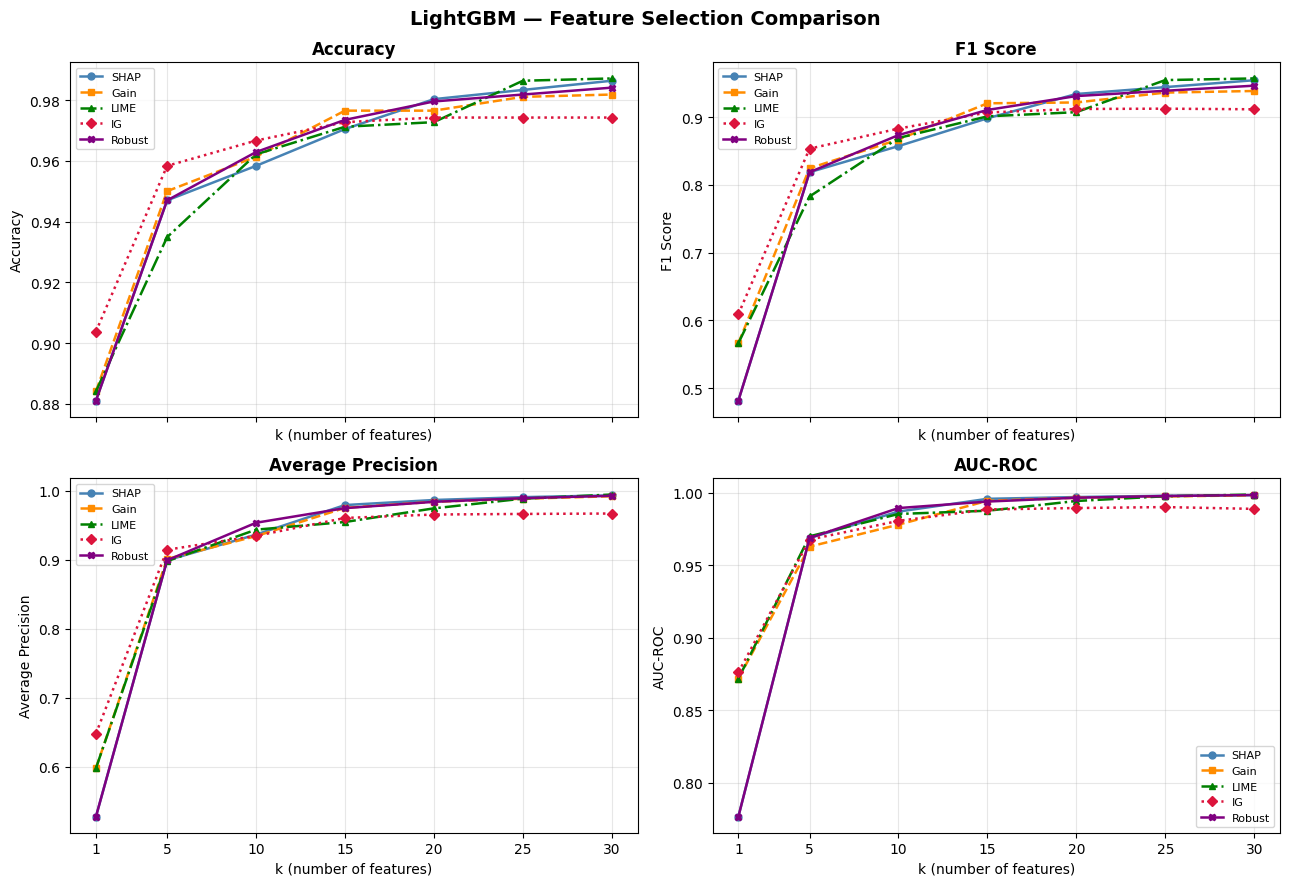

In [198]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating LightGBM — SHAP...')
lightgbm_res_shap = evaluate_topk(MODELS['LightGBM'], lightgbm_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Gain...')
lightgbm_res_gain = evaluate_topk(MODELS['LightGBM'], lightgbm_gain, X_train, X_test, y_train, y_test, k_values) if lightgbm_gain is not None else None

print('Evaluating LightGBM — LIME...')
lightgbm_res_lime = evaluate_topk(MODELS['LightGBM'], lightgbm_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — IG...')
lightgbm_res_ig = evaluate_topk(MODELS['LightGBM'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LightGBM — Robust Bootstrap...')
lightgbm_res_robust = evaluate_topk(MODELS['LightGBM'], lightgbm_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LightGBM',
    {'SHAP': lightgbm_res_shap, 'Gain': lightgbm_res_gain,
     'LIME': lightgbm_res_lime, 'IG':   lightgbm_res_ig, 'Robust': lightgbm_res_robust},
    k_values,
)


---
## XGBoost

### XGBoost — SHAP

In [199]:
print('Computing SHAP ranking for XGBoost...')
xgboost_shap = get_shap_ranking(MODELS['XGBoost'], X_train, y_train)
print('Top-10:')
xgboost_shap.head(10)


Computing SHAP ranking for XGBoost...
Top-10:


,feature,importance
0,f36,2531.104004
1,f163,1911.543457
2,f111,1797.959351
3,f1,1434.118164
4,f132,1183.177612
5,f151,1157.793091
6,f126,1131.438721
7,f25,1077.449951
8,f66,1053.375732
9,f59,1044.817383


### XGBoost — Gain

In [200]:
print('Computing Gain ranking for XGBoost...')
xgboost_gain = get_gain_ranking(MODELS['XGBoost'], X_train, y_train)
if xgboost_gain is not None:
    print('Top-10:')
    display(xgboost_gain.head(10))
else:
    print('Gain not supported for XGBoost')


Computing Gain ranking for XGBoost...
Top-10:


,feature,importance
0,f36,66.093292
1,f142,50.851555
2,f33,44.645840
3,f35,43.173836
4,f151,35.751968
5,f38,32.195656
6,f163,30.488253
7,f162,22.910191
8,f64,21.704788
9,f132,19.032671


### XGBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [201]:
print('Computing LIME ranking for XGBoost...')
xgboost_lime = get_lime_ranking(
    MODELS['XGBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
xgboost_lime.head(10)


Computing LIME ranking for XGBoost...
Top-10:


,feature,importance
0,f36,0.031016
1,f163,0.020904
2,f145,0.020609
3,f67,0.020036
4,f111,0.017394
5,f126,0.017025
6,f105,0.016087
7,f151,0.015746
8,f1,0.014937
9,f132,0.014679


### XGBoost — Robust

In [234]:
top60 = xgboost_shap['feature'].head(60).tolist()

In [235]:
xgb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train[top60],
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=xgb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [00:32<00:00, 15.17it/s]


In [236]:
xgb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=xgb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

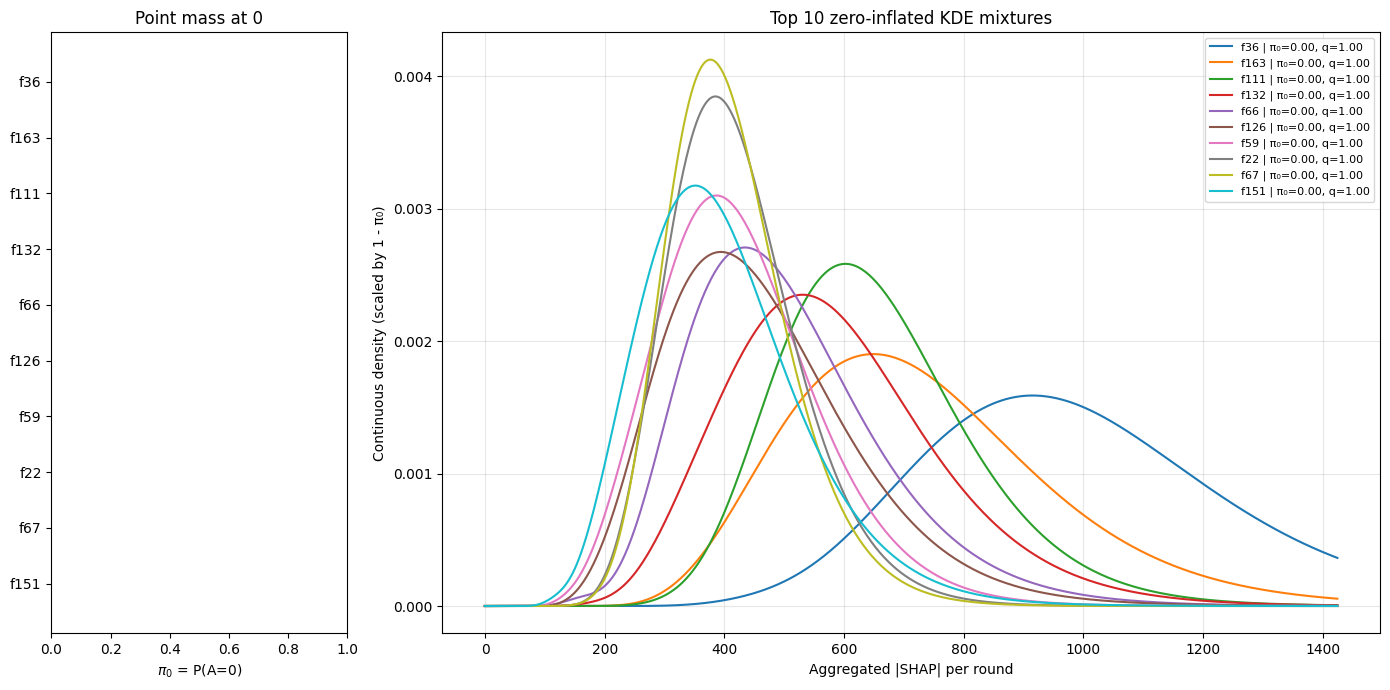

In [238]:
lgb_top = plot_top_feature_density(
    xgb_feature_kde,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
    # x_max=2e5,
)

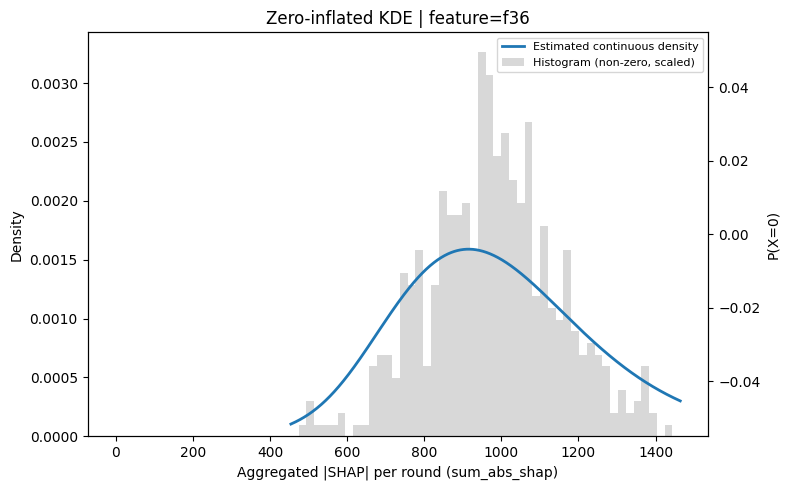

In [241]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=xgb_feature_kde,
    boot_results=xgb_boot_unscreen,
    feature="f36",
    bins = 50,
    # xlim=(0, 200000),
)

/tmp/ipykernel_2068677/124635710.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


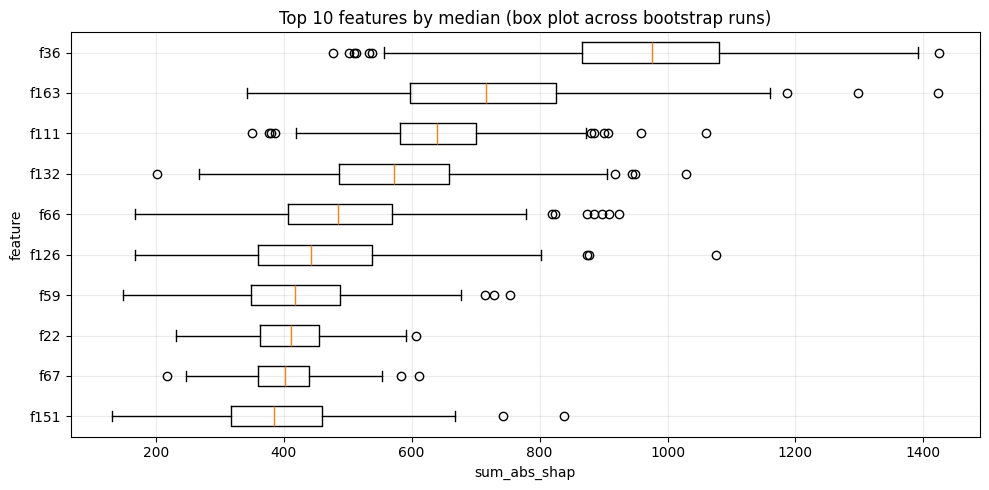

,feature,sum_abs_shap,bootstrap_id
0,f111,585.999023,0
1,f126,229.829437,0
2,f132,597.334351,0
3,f151,388.471100,0
4,f163,952.473877,0


In [243]:
# Box plot for top features (run-level aggregated SHAP values)
top_k = 10
score_col = "median"   # ranking metric from xgb_feature_kde
agg_col = "sum_abs_shap"      # column in each element of xgb_boot_results

ranked = (
    xgb_feature_kde[["feature", score_col]]
    .dropna(subset=[score_col])
    .sort_values(score_col, ascending=False)
)

top_features = ranked["feature"].astype(str).head(top_k).tolist()

box_rows = []
for b, res in enumerate(xgb_boot_unscreen):
    part = res.loc[:, ["feature", agg_col]].copy()
    part["feature"] = part["feature"].astype(str)
    part = part[part["feature"].isin(top_features)]
    part["bootstrap_id"] = b
    box_rows.append(part)

box_df = pd.concat(box_rows, ignore_index=True)
box_df = box_df.dropna(subset=[agg_col])

plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
plt.boxplot(
    plot_data,
    labels=top_features,
    vert=False,
    # showfliers=False,
    showfliers=True,
)
plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (box plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

box_df.head()

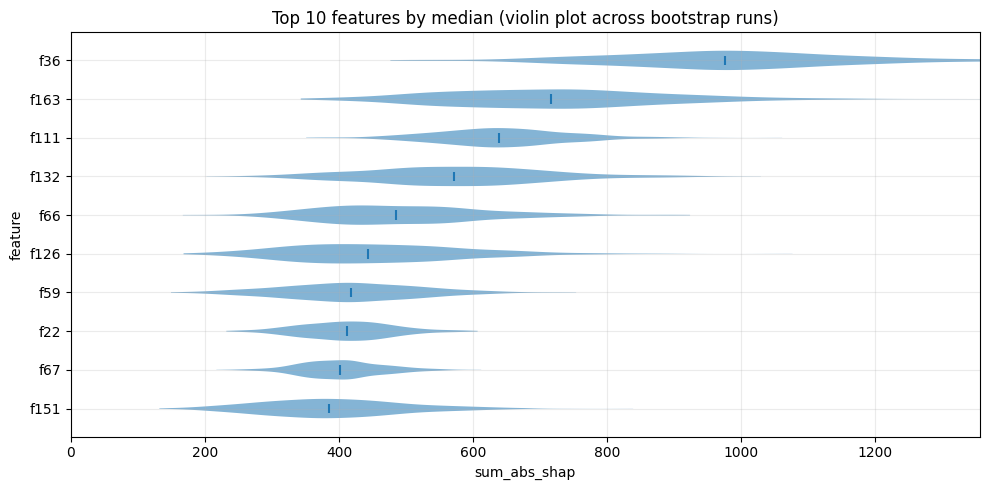

In [244]:
plot_data = [box_df.loc[box_df["feature"] == f, agg_col].to_numpy() for f in top_features]

plt.figure(figsize=(10, max(5, 0.45 * len(top_features))))
vp = plt.violinplot(
    plot_data,
    vert=False,
    showmeans=False,
    showmedians=True,
    showextrema=False,
)

for body in vp["bodies"]:
    body.set_alpha(0.55)

positions = np.arange(1, len(top_features) + 1)
plt.yticks(positions, top_features)

# robust x-axis (ignore extreme tail)
all_vals = np.concatenate(plot_data)
# x_lo = np.nanpercentile(all_vals, 1)
x_lo = 0
x_hi = np.nanpercentile(all_vals, 99.8)
plt.xlim(x_lo, x_hi)
plt.margins(x=0)

plt.xlabel(agg_col)
plt.ylabel("feature")
plt.title(f"Top {len(top_features)} features by {score_col} (violin plot across bootstrap runs)")
plt.grid(alpha=0.25)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [204]:
tmp = xgb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

xgboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
xgboost_robust.head(10)


,feature,importance
Rank,,
1,f36,3110.021087
2,f163,1797.291652
3,f111,1783.140746
4,f66,1519.029899
5,f132,1473.817012
6,f1,1270.634396
7,f25,1050.383138
8,f126,1020.520486
9,f105,963.486719


### XGBoost — Evaluation & Comparison

Evaluating XGBoost — SHAP...
Evaluating XGBoost — Gain...
Evaluating XGBoost — LIME...
Evaluating XGBoost — IG...
Evaluating XGBoost — Robust Bootstrap...


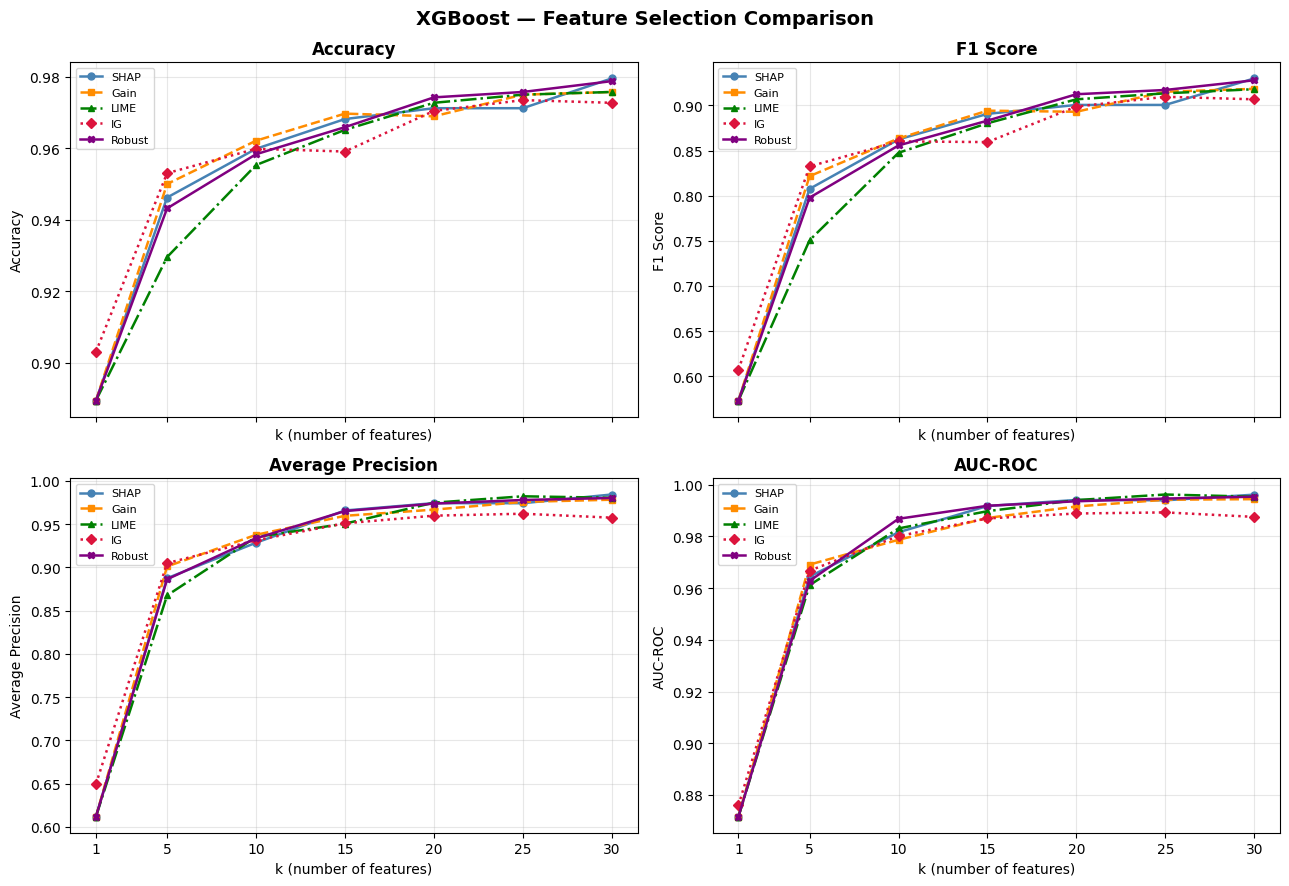

In [205]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating XGBoost — SHAP...')
xgboost_res_shap = evaluate_topk(MODELS['XGBoost'], xgboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Gain...')
xgboost_res_gain = evaluate_topk(MODELS['XGBoost'], xgboost_gain, X_train, X_test, y_train, y_test, k_values) if xgboost_gain is not None else None

print('Evaluating XGBoost — LIME...')
xgboost_res_lime = evaluate_topk(MODELS['XGBoost'], xgboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — IG...')
xgboost_res_ig = evaluate_topk(MODELS['XGBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating XGBoost — Robust Bootstrap...')
xgboost_res_robust = evaluate_topk(MODELS['XGBoost'], xgboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'XGBoost',
    {'SHAP': xgboost_res_shap, 'Gain': xgboost_res_gain,
     'LIME': xgboost_res_lime, 'IG':   xgboost_res_ig, 'Robust': xgboost_res_robust},
    k_values,
)

---
## RandomForest

### RandomForest — SHAP

In [206]:
print('Computing SHAP ranking for RandomForest...')
randomforest_shap = get_shap_ranking(MODELS['RandomForest'], X_train, y_train)
print('Top-10:')
randomforest_shap.head(10)


Computing SHAP ranking for RandomForest...
Top-10:


,feature,importance
0,f163,107.832141
1,f36,102.225613
2,f132,56.554524
3,f92,55.483026
4,f126,47.263359
5,f95,42.212583
6,f45,34.755582
7,f66,31.166702
8,f151,29.741561
9,f96,26.469459


### RandomForest — Gain

In [207]:
print('Computing Gain ranking for RandomForest...')
randomforest_gain = get_gain_ranking(MODELS['RandomForest'], X_train, y_train)
if randomforest_gain is not None:
    print('Top-10:')
    display(randomforest_gain.head(10))
else:
    print('Gain not supported for RandomForest')


Computing Gain ranking for RandomForest...
Top-10:


,feature,importance
0,f36,0.046980
1,f163,0.043485
2,f92,0.036636
3,f132,0.030775
4,f126,0.026080
5,f66,0.021214
6,f61,0.019957
7,f124,0.019691
8,f95,0.017044
9,f151,0.016785


### RandomForest — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [208]:
print('Computing LIME ranking for RandomForest...')
randomforest_lime = get_lime_ranking(
    MODELS['RandomForest'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
randomforest_lime.head(10)

Computing LIME ranking for RandomForest...
Top-10:


,feature,importance
0,f36,0.025133
1,f163,0.021055
2,f126,0.018462
3,f92,0.016559
4,f132,0.014881
5,f45,0.013365
6,f15,0.010233
7,f66,0.007967
8,f105,0.007583
9,f151,0.007288


### RandomForest — Robust

In [ ]:
# top60 = randomforest_shap['feature'].head(60).tolist()

In [209]:
rf_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1,
    zero_tol=0,
    model_wrapper=rf_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [05:22<00:00,  1.55it/s]


In [210]:
rf_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=rf_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [211]:
tmp = rf_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

rf_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
rf_robust.head(10)


,feature,importance
Rank,,
1,f36,115.086907
2,f163,112.354256
3,f132,78.786368
4,f126,67.113131
5,f92,55.907913
6,f95,51.065818
7,f66,37.129882
8,f151,29.028367
9,f124,27.043649


### RandomForest — Evaluation & Comparison

Evaluating RandomForest — SHAP...
Evaluating RandomForest — Gain...
Evaluating RandomForest — LIME...
Evaluating RandomForest — IG...
Evaluating RandomForest — Robust Bootstrap...


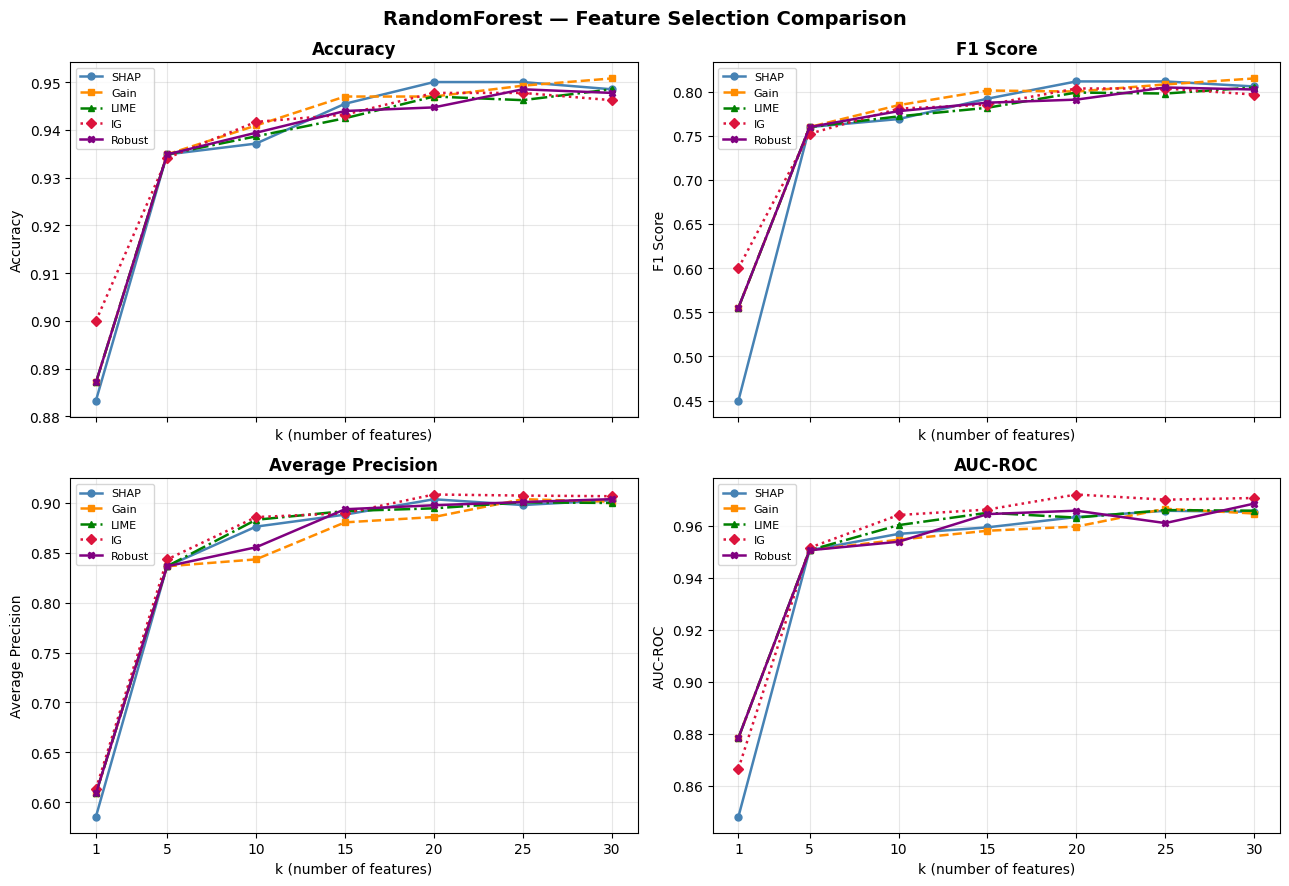

In [212]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating RandomForest — SHAP...')
randomforest_res_shap = evaluate_topk(MODELS['RandomForest'], randomforest_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Gain...')
randomforest_res_gain = evaluate_topk(MODELS['RandomForest'], randomforest_gain, X_train, X_test, y_train, y_test, k_values) if randomforest_gain is not None else None

print('Evaluating RandomForest — LIME...')
randomforest_res_lime = evaluate_topk(MODELS['RandomForest'], randomforest_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — IG...')
randomforest_res_ig = evaluate_topk(MODELS['RandomForest'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating RandomForest — Robust Bootstrap...')
randomforest_res_robust = evaluate_topk(MODELS['RandomForest'], rf_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'RandomForest',
    {'SHAP': randomforest_res_shap, 'Gain': randomforest_res_gain,
     'LIME': randomforest_res_lime, 'IG':   randomforest_res_ig, 'Robust': randomforest_res_robust},
    k_values,
)


---
## CatBoost

### CatBoost — SHAP

In [213]:
print('Computing SHAP ranking for CatBoost...')
catboost_shap = get_shap_ranking(MODELS['CatBoost'], X_train, y_train)
print('Top-10:')
catboost_shap.head(10)

Computing SHAP ranking for CatBoost...
Top-10:


,feature,importance
0,f66,1513.361834
1,f36,1253.619919
2,f160,1071.319918
3,f111,1041.243903
4,f163,984.913947
5,f105,833.651017
6,f91,781.506870
7,f67,712.534731
8,f59,705.119707
9,f1,670.477979


### CatBoost — Gain

In [214]:
print('Computing Gain ranking for CatBoost...')
catboost_gain = get_gain_ranking(MODELS['CatBoost'], X_train, y_train)
if catboost_gain is not None:
    print('Top-10:')
    display(catboost_gain.head(10))
else:
    print('Gain not supported for CatBoost')


Computing Gain ranking for CatBoost...
Top-10:


,feature,importance
0,f160,4.021579
1,f163,3.922565
2,f36,3.916238
3,f66,3.874672
4,f17,3.018277
5,f132,2.238721
6,f149,2.087184
7,f1,1.897979
8,f4,1.821046
9,f111,1.817543


### CatBoost — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [215]:
print('Computing LIME ranking for CatBoost...')
catboost_lime = get_lime_ranking(
    MODELS['CatBoost'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
catboost_lime.head(10)


Computing LIME ranking for CatBoost...
Top-10:


,feature,importance
0,f105,0.024953
1,f67,0.021503
2,f36,0.021217
3,f92,0.020303
4,f160,0.017648
5,f163,0.015434
6,f126,0.015048
7,f111,0.014593
8,f66,0.013302
9,f59,0.011418


### CatBoost — Robust

In [ ]:
# top60 = catboost_shap['feature'].head(60).tolist()

In [216]:
cb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=cb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg):   0%|          | 1/500 [00:05<46:01,  5.53s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   2%|▏         | 9/500 [00:12<10:55,  1.34s/it]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Bootstrap repeats (feature-agg):   2%|▏         | 12/500 [00:14<07:30,  1.08it/s]/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused

In [217]:
cb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [218]:
tmp = cb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

catboost_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
catboost_robust.head(10)


,feature,importance
Rank,,
1,f36,2060.000274
2,f66,1637.786982
3,f163,1346.451929
4,f111,1161.294139
5,f132,889.141908
6,f22,644.529508
7,f1,560.485276
8,f126,526.570289
9,f25,469.135040


### CatBoost — Evaluation & Comparison

Evaluating CatBoost — SHAP...
Evaluating CatBoost — Gain...
Evaluating CatBoost — LIME...
Evaluating CatBoost — IG...
Evaluating CatBoost — Robust Bootstrap...


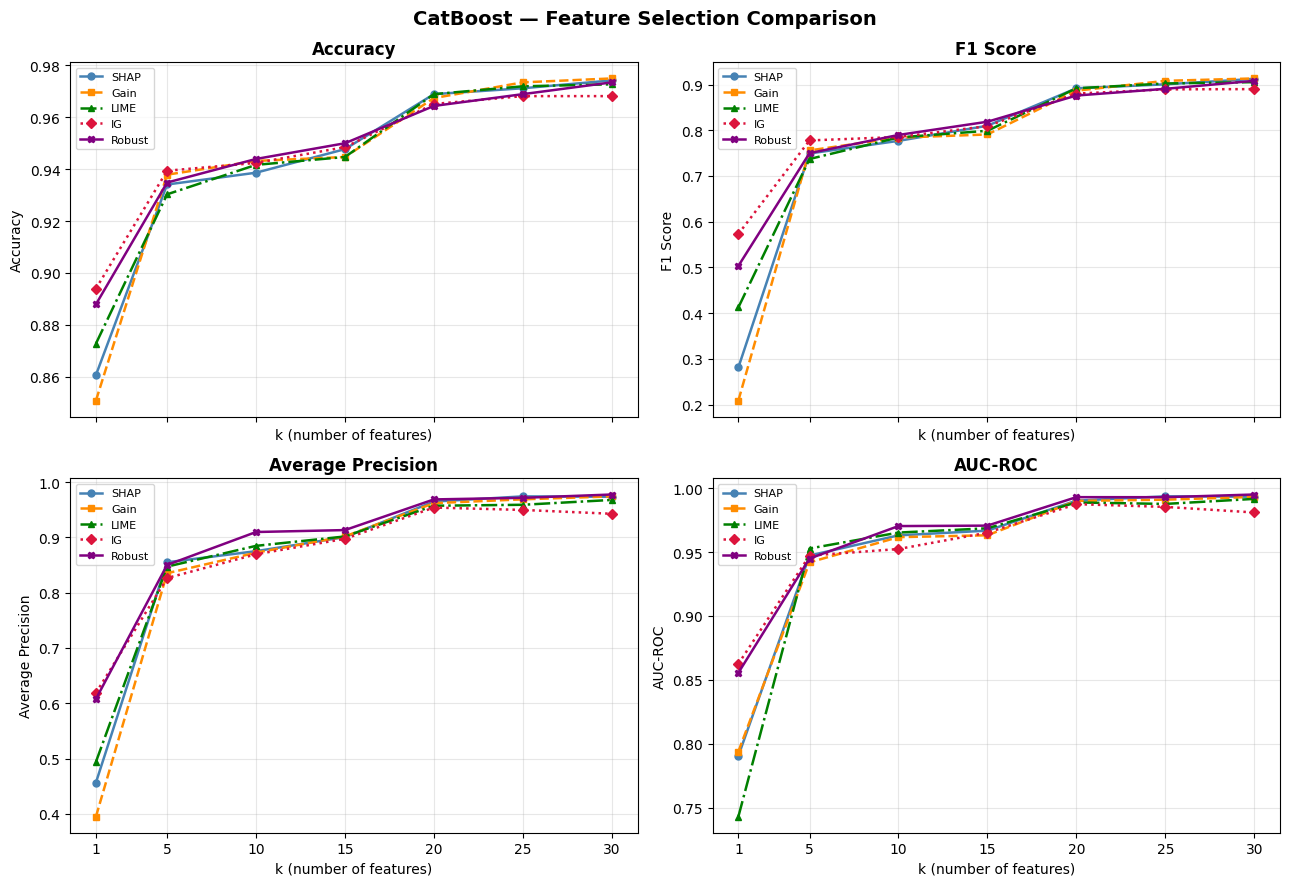

In [219]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating CatBoost — SHAP...')
catboost_res_shap = evaluate_topk(MODELS['CatBoost'], catboost_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Gain...')
catboost_res_gain = evaluate_topk(MODELS['CatBoost'], catboost_gain, X_train, X_test, y_train, y_test, k_values) if catboost_gain is not None else None

print('Evaluating CatBoost — LIME...')
catboost_res_lime = evaluate_topk(MODELS['CatBoost'], catboost_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — IG...')
catboost_res_ig = evaluate_topk(MODELS['CatBoost'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating CatBoost — Robust Bootstrap...')
catboost_res_robust = evaluate_topk(MODELS['CatBoost'], catboost_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'CatBoost',
    {'SHAP': catboost_res_shap, 'Gain': catboost_res_gain,
     'LIME': catboost_res_lime, 'IG':   catboost_res_ig, 'Robust': catboost_res_robust},
    k_values,
)


---
## GradientBoosting

### GradientBoosting — SHAP

In [220]:
print('Computing SHAP ranking for GradientBoosting...')
gradientboosting_shap = get_shap_ranking(MODELS['GradientBoosting'], X_train, y_train)
print('Top-10:')
gradientboosting_shap.head(10)

Computing SHAP ranking for GradientBoosting...
Top-10:


,feature,importance
0,f163,2086.328197
1,f36,1960.114681
2,f111,1564.368103
3,f1,1555.617770
4,f66,1378.519474
5,f59,1211.667606
6,f67,875.663829
7,f22,844.845064
8,f105,837.579948
9,f25,812.595424


### GradientBoosting — Gain

In [221]:
print('Computing Gain ranking for GradientBoosting...')
gradientboosting_gain = get_gain_ranking(MODELS['GradientBoosting'], X_train, y_train)
if gradientboosting_gain is not None:
    print('Top-10:')
    display(gradientboosting_gain.head(10))
else:
    print('Gain not supported for GradientBoosting')


Computing Gain ranking for GradientBoosting...
Top-10:


,feature,importance
0,f36,0.146878
1,f163,0.072143
2,f151,0.067877
3,f9,0.060359
4,f33,0.045324
5,f124,0.044817
6,f165,0.042825
7,f132,0.035682
8,f126,0.028296
9,f66,0.024921


### GradientBoosting — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [222]:
print('Computing LIME ranking for GradientBoosting...')
gradientboosting_lime = get_lime_ranking(
    MODELS['GradientBoosting'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
gradientboosting_lime.head(10)

Computing LIME ranking for GradientBoosting...


Top-10:


,feature,importance
0,f36,0.064099
1,f163,0.035740
2,f132,0.028678
3,f111,0.026381
4,f67,0.026050
5,f1,0.023096
6,f145,0.022753
7,f126,0.020469
8,f3,0.019056
9,f102,0.018360


### GradientBoosting — Robust

In [ ]:
# top60 = gradientboosting_shap['feature'].head(60).tolist()

In [223]:
gb_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=gb_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [1:04:50<00:00,  7.78s/it]


In [224]:
gb_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=gb_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [225]:
tmp = gb_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

gradientboosting_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
gradientboosting_robust.head(10)


,feature,importance
Rank,,
1,f36,2563.281812
2,f163,2478.853450
3,f66,1936.369652
4,f111,1776.506671
5,f1,1411.903632
6,f67,1002.272674
7,f132,932.120942
8,f105,753.474216
9,f162,688.846675


### GradientBoosting — Evaluation & Comparison

Evaluating GradientBoosting — SHAP...


Evaluating GradientBoosting — Gain...
Evaluating GradientBoosting — LIME...
Evaluating GradientBoosting — IG...
Evaluating GradientBoosting — Robust Bootstrap...


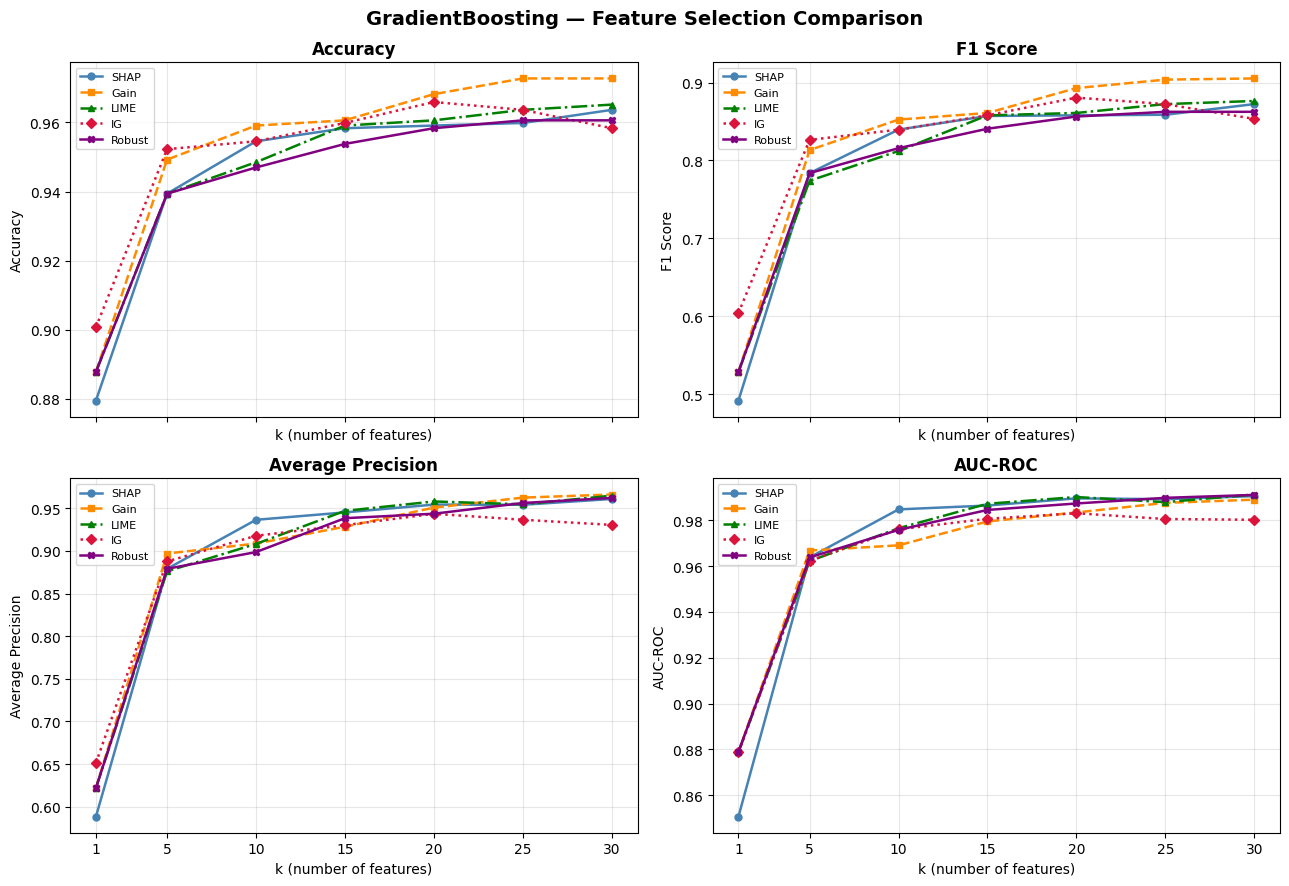

In [226]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating GradientBoosting — SHAP...')
gradientboosting_res_shap = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Gain...')
gradientboosting_res_gain = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_gain, X_train, X_test, y_train, y_test, k_values) if gradientboosting_gain is not None else None

print('Evaluating GradientBoosting — LIME...')
gradientboosting_res_lime = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — IG...')
gradientboosting_res_ig = evaluate_topk(MODELS['GradientBoosting'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating GradientBoosting — Robust Bootstrap...')
gradientboosting_res_robust = evaluate_topk(MODELS['GradientBoosting'], gradientboosting_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'GradientBoosting',
    {'SHAP': gradientboosting_res_shap, 'Gain': gradientboosting_res_gain,
     'LIME': gradientboosting_res_lime, 'IG':   gradientboosting_res_ig, 'Robust': gradientboosting_res_robust},
    k_values,
)


---
## LogisticRegression

### LogisticRegression — SHAP

In [227]:
print('Computing SHAP ranking for LogisticRegression...')
logisticregression_shap = get_shap_ranking(MODELS['LogisticRegression'], X_train, y_train)
print('Top-10:')
logisticregression_shap.head(10)

Computing SHAP ranking for LogisticRegression...


Top-10:


,feature,importance
0,f99,14056.729828
1,f17,11565.033210
2,f118,10231.779864
3,f119,9426.506866
4,f114,8838.031342
5,f78,8017.954961
6,f41,7461.012082
7,f71,6973.799480
8,f52,6711.312574
9,f85,6642.952863


### LogisticRegression — Gain

In [228]:
print('Computing Gain ranking for LogisticRegression...')
logisticregression_gain = get_gain_ranking(MODELS['LogisticRegression'], X_train, y_train)
if logisticregression_gain is not None:
    print('Top-10:')
    display(logisticregression_gain.head(10))
else:
    print('Gain not supported for LogisticRegression')


Computing Gain ranking for LogisticRegression...
Top-10:


,feature,importance
0,f99,2.826522
1,f17,2.435502
2,f118,2.096546
3,f119,1.956339
4,f114,1.842366
5,f78,1.776371
6,f41,1.622090
7,f149,1.544868
8,f71,1.486954
9,f85,1.412705


### LogisticRegression — LIME

_Adjust `n_samples` and `num_features` to trade speed for accuracy._

In [229]:
print('Computing LIME ranking for LogisticRegression...')
logisticregression_lime = get_lime_ranking(
    MODELS['LogisticRegression'], X_train, y_train,
    n_samples=10,    # increase for better estimates
    num_features=50, # top features per explanation
)
print('Top-10:')
logisticregression_lime.head(10)


Computing LIME ranking for LogisticRegression...


Top-10:


,feature,importance
0,f17,0.098617
1,f99,0.096588
2,f118,0.091856
3,f119,0.090009
4,f78,0.068662
5,f114,0.064084
6,f125,0.057143
7,f130,0.053418
8,f50,0.049351
9,f100,0.047519


### LogisticRegression — Robust

In [ ]:
# top60 = logisticregression_shap['feature'].head(60).tolist()

In [230]:
lr_boot_unscreen = boot_multi_repeat_inference_keep_feature(
    X=X_train,
    y=y_train,
    inner_variance="permutation",
    task="binary",
    n_bootstrap=500,  
    b_model=1, 
    zero_tol=0,
    model_wrapper=lr_wrapper,  
    n_jobs=6,        
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 500/500 [13:06<00:00,  1.57s/it]


In [231]:
lr_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=lr_boot_unscreen,
    bandwidth=0.2,
    kernel="gaussian",
    zero_tol=1e-8
)

In [232]:
tmp = lr_feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["nonzero_median"] * tmp["SNR"]
                                
top = tmp.nlargest(30, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
# top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
#     "feature": "Group",
#     "stat": "importance",
#     "nonzero_median": "Median",
#     "sd_estimated": "Std",
# }).round(3)

logisticregression_robust = top[['feature', 'stat']].rename(columns={'stat': 'importance'})
logisticregression_robust.head(10)


,feature,importance
Rank,,
1,f99,16538.138268
2,f17,14807.655295
3,f118,12418.785027
4,f114,10394.681477
5,f119,9851.473087
6,f78,9313.628875
7,f41,8514.103002
8,f71,8331.070215
9,f149,7513.074798


### LogisticRegression — Evaluation & Comparison

Evaluating LogisticRegression — SHAP...


Evaluating LogisticRegression — Gain...
Evaluating LogisticRegression — LIME...
Evaluating LogisticRegression — IG...
Evaluating LogisticRegression — Robust Bootstrap...


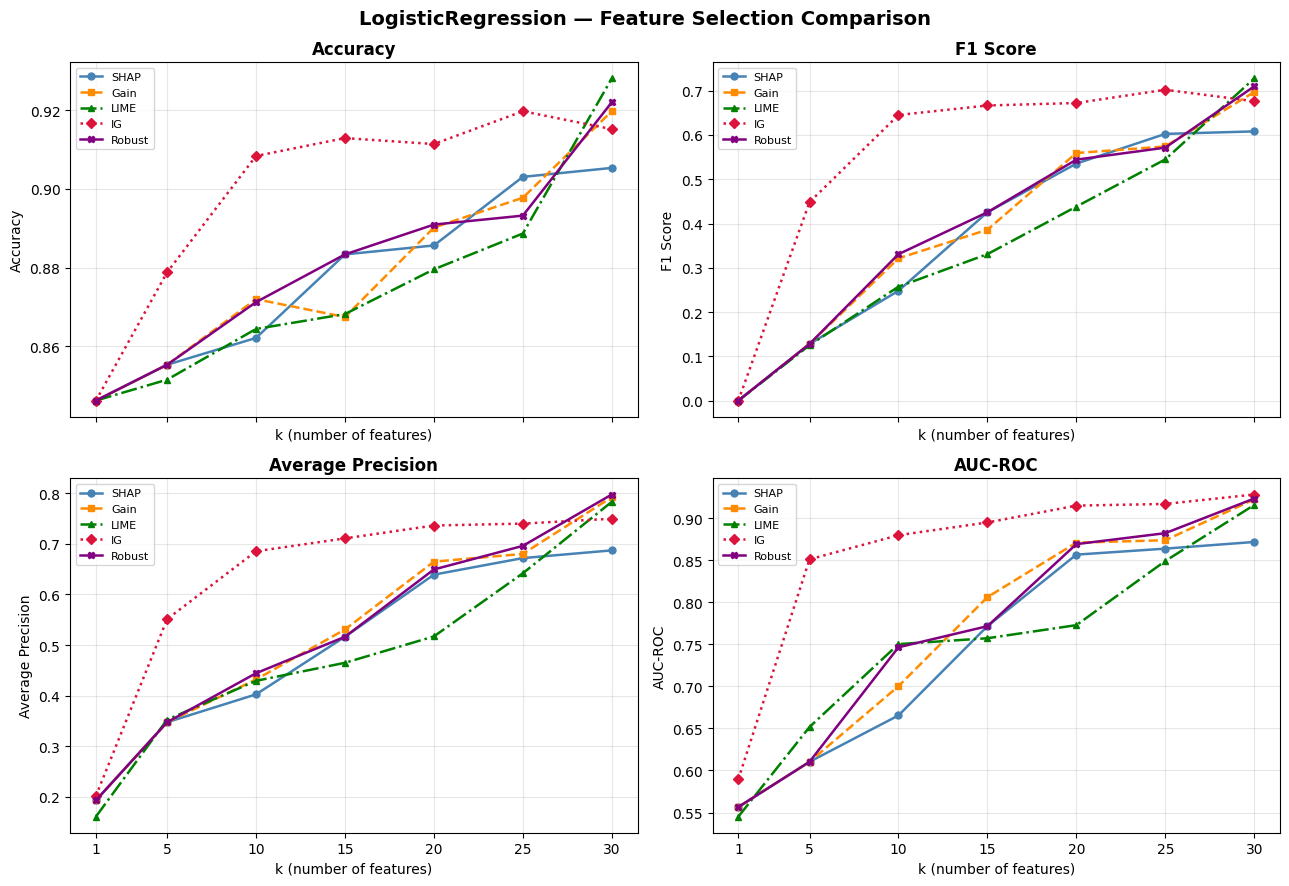

In [233]:
k_values = [1, 5, 10, 15, 20, 25, 30]

print('Evaluating LogisticRegression — SHAP...')
logisticregression_res_shap = evaluate_topk(MODELS['LogisticRegression'], logisticregression_shap, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — Gain...')
logisticregression_res_gain = evaluate_topk(MODELS['LogisticRegression'], logisticregression_gain, X_train, X_test, y_train, y_test, k_values) if logisticregression_gain is not None else None

print('Evaluating LogisticRegression — LIME...')
logisticregression_res_lime = evaluate_topk(MODELS['LogisticRegression'], logisticregression_lime, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — IG...')
logisticregression_res_ig = evaluate_topk(MODELS['LogisticRegression'], ig_ranking, X_train, X_test, y_train, y_test, k_values)

print('Evaluating LogisticRegression — Robust Bootstrap...')
logisticregression_res_robust = evaluate_topk(MODELS['LogisticRegression'], logisticregression_robust, X_train, X_test, y_train, y_test, k_values)

plot_comparison(
    'LogisticRegression',
    {'SHAP': logisticregression_res_shap, 'Gain': logisticregression_res_gain,
     'LIME': logisticregression_res_lime, 'IG':   logisticregression_res_ig, 'Robust': logisticregression_res_robust},
    k_values,
)
